###---Unzip Dataset---

In [ ]:
import os
from google.colab import drive

# 1. Mount Drive
drive.mount('/content/drive') ##Fill in yourself to specify a different location if you want, but this is the default and works well for most users.

# 2. Define your project folder path
# Change this to match your folder name in Drive
project_path = '' #fill your own path here where you want the dataset to be located. You can also create a new folder in Drive and point to that if you want to keep things organized.

# 3. Unzip directly from that folder to the local Colab disk
# Using -q (quiet) keeps the output clean since you have 5,000+ files
zip_path = os.path.join(project_path, 'pneumoniaDataset.zip')

!unzip -q "{zip_path}" -d /content/dataset/

print("✅ Unzipped! Your images are now at /content/dataset/") #change this if you unzipped to a different location

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
d
✅ Unzipped! Your images are now at /content/dataset/


Check if zip is succesfully unzipped

In [ ]:
base_dir = '/content/dataset/chest_xray/'
print("Contents of /content/dataset/chest_xray/:", os.listdir(base_dir))

Contents of /content/dataset/chest_xray/: ['train', 'chest_xray', 'val', '__MACOSX', 'test']


###---Data Preparation---

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import os

# 1. Define the path (Make sure this matches your 'Internal' folder check)
data_root = '/content/dataset/chest_xray/'

# 2. Setup the "Augmentation" rules
train_datagen = ImageDataGenerator(
    # Scales pixel values from 0-255 to -1 to 1 (Required for MobileNetV2 math)
    preprocessing_function=tf.keras.applications.mobilenet_v2.preprocess_input,

    # Randomly tilts the image up to 20 degrees (Simulates slight patient movement)
    rotation_range=20,

    # Randomly moves the image left or right by 10% (Simulates off-center positioning)
    width_shift_range=0.1,

    # Randomly moves the image up or down by 10% (Simulates different breathing depths)
    height_shift_range=0.1,

    # Distorts the image by 10% (Simulates perspective/angle differences)
    shear_range=0.1,

    # Randomly zooms in or out by 20% (Simulates the camera being closer or further)
    zoom_range=0.2,

    # Flips the image horizontally (Doubles the data; lungs are mostly symmetrical)
    horizontal_flip=True,

    # When an image rotates/shifts, this fills in the 'empty' edge pixels with the nearest color
    fill_mode='nearest'
)

# 3. Setup the "Test" rules (NO augmentation here!)
test_datagen = ImageDataGenerator(
    preprocessing_function=tf.keras.applications.mobilenet_v2.preprocess_input
)

# 4. Create the actual generators
train_generator = train_datagen.flow_from_directory(
    os.path.join(data_root, 'train'),
    target_size=(224, 224),     # Required size for MobileNetV2
    batch_size=32,
    class_mode='binary'         # Normal vs Pneumonia
)

test_generator = test_datagen.flow_from_directory(
    os.path.join(data_root, 'test'),
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary'
)

Found 5216 images belonging to 2 classes.
Found 624 images belonging to 2 classes.


Class Weight Prepping

In [ ]:
import os

# 1. Define the specific training paths
train_normal_dir = '/content/dataset/chest_xray/train/NORMAL'
train_pneumonia_dir = '/content/dataset/chest_xray/train/PNEUMONIA'

# 2. Count the files in each folder
# len(os.listdir()) counts the number of items in the folder
count_normal = len(os.listdir(train_normal_dir))
count_pneumonia = len(os.listdir(train_pneumonia_dir))

# 3. Calculate the total
total_samples = count_normal + count_pneumonia

# 4. Calculate the "Importance" weights
# Formula: (1 / class_count) * (total_samples / 2.0)
weight_for_0 = (1 / count_normal) * (total_samples / 2.0)
weight_for_1 = (1 / count_pneumonia) * (total_samples / 2.0)

class_weight = {0: weight_for_0, 1: weight_for_1}

# 5. Output the results
print(f"--- Data Preparation Summary ---")
print(f"Normal images: {count_normal}")
print(f"Pneumonia images: {count_pneumonia}")
print(f"Total training samples: {total_samples}")
print(f"---------------------------------")
print(f"Weight for Class 0 (Normal): {weight_for_0:.2f}")
print(f"Weight for Class 1 (Pneumonia): {weight_for_1:.2f}")

--- Data Preparation Summary ---
Normal images: 1341
Pneumonia images: 3875
Total training samples: 5216
---------------------------------
Weight for Class 0 (Normal): 1.94
Weight for Class 1 (Pneumonia): 0.67


Loading Data

In [ ]:
import tensorflow as tf

# Load the actual images into the train_ds variable
train_ds = tf.keras.utils.image_dataset_from_directory(
    '/content/dataset/chest_xray/train',
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(224, 224), # Make sure this matches your model's input
    batch_size=32
)

# Also create a validation set so you can see how it learns
val_ds = tf.keras.utils.image_dataset_from_directory(
    '/content/dataset/chest_xray/train',
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(224, 224),
    batch_size=32
)

Found 5216 files belonging to 2 classes.
Using 4173 files for training.
Found 5216 files belonging to 2 classes.
Using 1043 files for validation.


###Choosing A Model (AND HYPERPARAMS)

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models

# 1. Load MobileNetV2 - Keep it frozen for the initial phase
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False

# 2. Build the Upgraded Architecture
model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),

    # TUNED: Increased to 256 neurons for more "brain power"
    layers.Dense(256, activation='relu'),

    # NEW: BatchNormalization stabilizes training and helps speed up convergence
    layers.BatchNormalization(),

    # TUNED: Kept at 0.5 to strictly prevent overfitting on the training set
    layers.Dropout(0.5),

    # NEW: A second smaller layer to refine the decision
    layers.Dense(64, activation='relu'),

    layers.Dense(1, activation='sigmoid')
])

# 3. Compile with Tuned Learning Rate
model.compile(
    # TUNED: Dropped to 0.0001 (10x slower) for a more stable, precise "fit"
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.Recall()]
)

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,603,457 (9.93 MB)

 Trainable params: 344,961 (1.32 MB)

 Non-trainable params: 2,258,496 (8.62 MB)

###Training

Epochs and Batch

In [ ]:
EPOCHS = 15
#Batch Size is 32, already in the upper code

Starting the training

In [ ]:
history = model.fit(
    train_generator,           # Use the generator with augmentation/rescaling
    validation_data=test_generator, # Use the test generator for validation
    epochs=EPOCHS,                 # 10 is usually enough for Transfer Learning
    class_weight=class_weight  # Keep this to help with the imbalance
)

Epoch 1/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 352s 2s/step - accuracy: 0.8386 - loss: 0.3412 - recall_2: 0.8204 - val_accuracy: 0.8606 - val_loss: 0.3040 - val_recall_2: 0.9154
Epoch 2/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 332s 2s/step - accuracy: 0.9005 - loss: 0.2210 - recall_2: 0.8815 - val_accuracy: 0.8846 - val_loss: 0.2495 - val_recall_2: 0.9385
Epoch 3/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 345s 2s/step - accuracy: 0.9174 - loss: 0.1845 - recall_2: 0.9043 - val_accuracy: 0.8910 - val_loss: 0.2276 - val_recall_2: 0.9385
Epoch 4/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 333s 2s/step - accuracy: 0.9283 - loss: 0.1733 - recall_2: 0.9210 - val_accuracy: 0.8862 - val_loss: 0.2336 - val_recall_2: 0.9282
Epoch 5/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 393s 2s/step - accuracy: 0.9367 - loss: 0.1561 - recall_2: 0.9311 - val_accuracy: 0.8910 - val_loss: 0.2333 - val_recall_2: 0.9308
Epoch 6/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 345s 2s/step - accuracy: 0.9400 - loss: 0.1471 - recall_2: 0.9352 - val_accuracy: 0.8926 - val_loss: 0.25

Save the ML process

In [ ]:
# Define where to save the model in your Drive
save_path = os.path.join(project_path, 'brain_pneumonia_model.keras')

# Save the trained model
model.save(save_path)

print(f"✅ Model saved to Google Drive at: {save_path}")

✅ Model saved to Google Drive at: /content/drive/MyDrive/Colab Notebooks/ML/Project Akhir/brain_pneumonia_model.keras


Load ML brain

In [ ]:
import tensorflow as tf

model = tf.keras.models.load_model('/content/drive/MyDrive/Colab Notebooks/ML/Project Akhir/brain_pneumonia_model.keras')

###Evaluation (TESTING)

In [ ]:
# 1. Load the Test Dataset
test_ds = tf.keras.utils.image_dataset_from_directory(
    '/content/dataset/chest_xray/test',
    image_size=(224, 224),
    batch_size=32
)

# 2. Evaluate the model
results = model.evaluate(test_ds)

print(f"\n--- Final Test Results ---")
print(f"Test Accuracy: {results[1]*100:.2f}%")
print(f"Test Recall (Sensitivity): {results[2]*100:.2f}%")

Found 624 files belonging to 2 classes.
20/20 ━━━━━━━━━━━━━━━━━━━━ 31s 1s/step - accuracy: 0.6314 - loss: 1.2541 - recall_2: 0.9949

--- Final Test Results ---
Test Accuracy: 63.14%
Test Recall (Sensitivity): 99.49%


Check Confusion Matrix

20/20 ━━━━━━━━━━━━━━━━━━━━ 33s 1s/step


<Axes: >

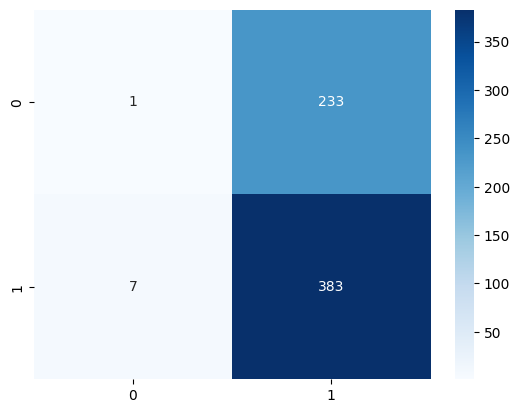

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import numpy as np

# Get all predictions
y_pred = (model.predict(test_ds) > 0.5).astype("int32")
y_true = np.concatenate([y for x, y in test_ds], axis=0)

cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
# Look at the "False Positives" vs "False Negatives"

Fine Tuning

In [ ]:
# 1. Unfreeze the base model
base_model.trainable = True

# 2. Let's unfreeze only the LAST 20-30 layers of MobileNetV2
# This prevents the early layers (basic shapes) from getting "corrupted"
# while allowing the high-level layers to learn lung textures.
for layer in base_model.layers[:-30]:
    layer.trainable = False

# 3. RE-CALCULATE CLASS WEIGHTS (More aggressive)
# We are going to manually double the penalty for missing a Normal case (Class 0)
# because the current weights aren't strong enough.
custom_class_weight = {0: weight_for_0 * 2.0, 1: weight_for_1}

# 4. Re-compile with a slightly faster Fine-Tuning rate
# 5e-5 is a bit faster than 1e-5; it gives the model more "energy" to change its mind.
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=5e-5),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.Recall()]
)

# 5. Fine-Tune
history_fine = model.fit(
    train_generator,
    validation_data=test_generator,
    epochs=10,
    class_weight=custom_class_weight
)

Epoch 1/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 343s 2s/step - accuracy: 0.9509 - loss: 0.1442 - recall_3: 0.9432 - val_accuracy: 0.9135 - val_loss: 0.2111 - val_recall_3: 0.9590
Epoch 2/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 329s 2s/step - accuracy: 0.9450 - loss: 0.1549 - recall_3: 0.9360 - val_accuracy: 0.9103 - val_loss: 0.2186 - val_recall_3: 0.9333
Epoch 3/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 380s 2s/step - accuracy: 0.9477 - loss: 0.1559 - recall_3: 0.9391 - val_accuracy: 0.9119 - val_loss: 0.2185 - val_recall_3: 0.9513
Epoch 4/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 330s 2s/step - accuracy: 0.9490 - loss: 0.1498 - recall_3: 0.9394 - val_accuracy: 0.9135 - val_loss: 0.2231 - val_recall_3: 0.9513
Epoch 5/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 327s 2s/step - accuracy: 0.9429 - loss: 0.1675 - recall_3: 0.9316 - val_accuracy: 0.9071 - val_loss: 0.2151 - val_recall_3: 0.9231
Epoch 6/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 341s 2s/step - accuracy: 0.9454 - loss: 0.1604 - recall_3: 0.9357 - val_accuracy: 0.9183 - val_loss: 0.20

Save v2 model

In [ ]:
# Save this as Version 2
save_path_v2 = os.path.join(project_path, 'brain_pneumonia_v2_finetuned.keras')
model.save(save_path_v2)
print(f"✅ Fine-tuned model saved as Version 2: {save_path_v2}")

✅ Fine-tuned model saved as Version 2: /content/drive/MyDrive/Colab Notebooks/ML/Project Akhir/brain_pneumonia_v2_finetuned.keras


In [ ]:
import tensorflow as tf
import os

# 1. Define the path exactly where you saved it
model_load_path = os.path.join(project_path, 'brain_pneumonia_v2_finetuned.keras')

# 2. Load the model
# We use compile=True so it brings back the optimizer settings too
model = tf.keras.models.load_model(model_load_path)

print(f"✅ Brain Re-Animated! Model loaded from: {model_load_path}")

# 3. Quick check to make sure it's the right one
model.summary()

✅ Brain Re-Animated! Model loaded from: /content/drive/MyDrive/Colab Notebooks/ML/Project Akhir/brain_pneumonia_v2_finetuned.keras


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,293,381 (12.56 MB)

 Trainable params: 344,961 (1.32 MB)

 Non-trainable params: 2,258,496 (8.62 MB)

 Optimizer params: 689,924 (2.63 MB)

Test v2 and matrix

In [ ]:
# 1. Load the Test Dataset
test_ds = tf.keras.utils.image_dataset_from_directory(
    '/content/dataset/chest_xray/test',
    image_size=(224, 224),
    batch_size=32,
    shuffle=False # Crucial for the confusion matrix later!
)

# 2. Add Preprocessing (The MobileNetV2 Scale)
test_ds = test_ds.map(lambda x, y: (tf.keras.applications.mobilenet_v2.preprocess_input(x), y))

# 3. Evaluate the model
results = model.evaluate(test_ds)

print(f"\n--- Final Test Results ---")
print(f"Test Accuracy: {results[1]*100:.2f}%")
# results[2] is Recall if you included it in your model.compile metrics
print(f"Test Recall (Sensitivity): {results[2]*100:.2f}%")

Found 624 files belonging to 2 classes.
20/20 ━━━━━━━━━━━━━━━━━━━━ 34s 1s/step - accuracy: 0.9151 - loss: 0.2312 - recall_3: 0.9590

--- Final Test Results ---
Test Accuracy: 91.51%
Test Recall (Sensitivity): 95.90%


Print confusion matrix

20/20 ━━━━━━━━━━━━━━━━━━━━ 31s 1s/step


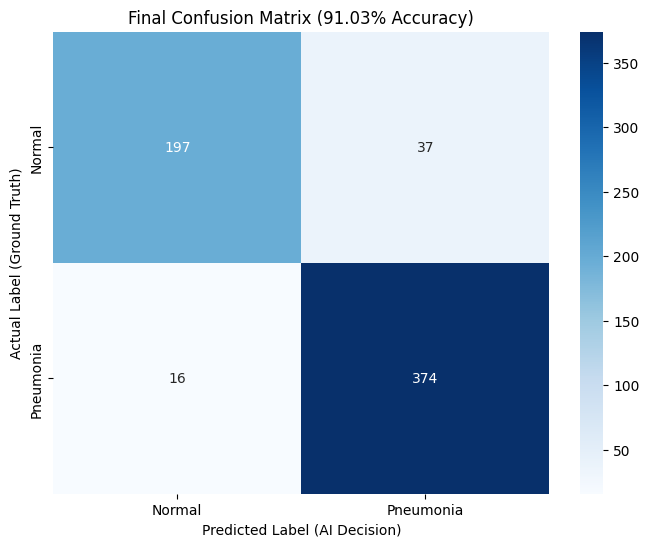


--- Final Performance Report ---
              precision    recall  f1-score   support

      Normal       0.92      0.84      0.88       234
   Pneumonia       0.91      0.96      0.93       390

    accuracy                           0.92       624
   macro avg       0.92      0.90      0.91       624
weighted avg       0.92      0.92      0.91       624



In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# 1. Get all true labels from the dataset
# Since shuffle=False in your test_ds, these will be in perfect order
y_true = np.concatenate([y for x, y in test_ds], axis=0)

# 2. Get the model's raw predictions
y_pred_probs = model.predict(test_ds)

# 3. Convert probabilities to binary (0 or 1)
# Using 0.5 as the decision threshold
y_pred = (y_pred_probs > 0.5).astype(int)

# 4. Create the Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

# 5. Plotting
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Pneumonia'],
            yticklabels=['Normal', 'Pneumonia'])

plt.title('Final Confusion Matrix (91.03% Accuracy)')
plt.ylabel('Actual Label (Ground Truth)')
plt.xlabel('Predicted Label (AI Decision)')
plt.show()

# 6. Print the full technical breakdown
print("\n--- Final Performance Report ---")
print(classification_report(y_true, y_pred, target_names=['Normal', 'Pneumonia']))

Save Final model

In [ ]:
# Final Save with the 91% verification
final_model_path = os.path.join(project_path, 'pneumonia_final.keras')
model.save(final_model_path)
print(f"✅ Final Production Model Saved: {final_model_path}")

✅ Final Production Model Saved: /content/drive/MyDrive/Colab Notebooks/ML/Project Akhir/pneumonia_final.keras


In [ ]:
# 1. Load the Test Dataset
test_ds = tf.keras.utils.image_dataset_from_directory(
    '/content/dataset/chest_xray/test',
    image_size=(224, 224),
    batch_size=32,
    shuffle=False # Crucial for the confusion matrix later!
)

# 2. Add Preprocessing (The MobileNetV2 Scale)
test_ds = test_ds.map(lambda x, y: (tf.keras.applications.mobilenet_v2.preprocess_input(x), y))

# 3. Evaluate the model
results = model.evaluate(test_ds)

print(f"\n--- Final Test Results ---")
print(f"Test Accuracy: {results[1]*100:.2f}%")
# results[2] is Recall if you included it in your model.compile metrics
print(f"Test Recall (Sensitivity): {results[2]*100:.2f}%")

Found 624 files belonging to 2 classes.
20/20 ━━━━━━━━━━━━━━━━━━━━ 32s 1s/step - accuracy: 0.9151 - loss: 0.2312 - recall_3: 0.9590

--- Final Test Results ---
Test Accuracy: 91.51%
Test Recall (Sensitivity): 95.90%
